In [ ]:
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._cosine_similarity import _cosine_similarity
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
import math
import numpy as np

In [2]:
N = 15
sigma = 10.
device = 'cuda'

filters = _gabor_like_filters(N, sigma)

filters = filters.astype("complex64")
filters = torch.tensor(filters)

abs_filters = torch.abs(filters)

filter_amount = filters.size(dim=0)


filters = filters.view(-1, N*N)
abs_filters = abs_filters.view(filter_amount, -1)


filter_list = []

filter_list.append(filters.real)
filter_list.append(filters.imag)

filters = torch.vstack(filter_list)

print(filters.shape)

/cluster/home/vetletb/projects/Bacheloroppgave-gr82-feature-extraction/src/gabor_like/external/_gaussian.py:21: RuntimeWarning: invalid value encountered in divide
  (n + np.array([l1, l2]).reshape(-1, 1, 1))


torch.Size([114, 225])


torch.Size([1, 1, 16, 16])


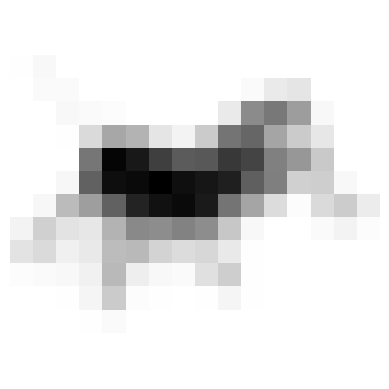

In [3]:
transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((N+1, N+1)),
        transforms.ToTensor(),
    ]
)
dataset = ImageFolder(root="image", transform=transform)

loader = torch.utils.data.DataLoader(
    dataset, batch_size=1, shuffle=False, pin_memory=True
)

it = iter(loader)
image = next(it)

print(image[0].shape)
plt.imshow(image[0][0][0], cmap="gray")
plt.axis("off")
plt.show()

In [4]:
unfold = torch.nn.Unfold(
    kernel_size=(N, N), padding=int((N-1)/2)
)

unfolded = unfold(image[0])
print(unfolded.shape)


filters_normalized = torch.nn.functional.normalize(filters, dim=1)

filters_normalized = filters_normalized.to(device=device)
unfolded = unfolded.to(device=device)
abs_filters = abs_filters.to(device=device)

features = _cosine_similarity(
    filters_normalized, unfolded, abs_filters
)

print(features.shape)

torch.Size([1, 225, 256])
torch.Size([1, 114, 256])


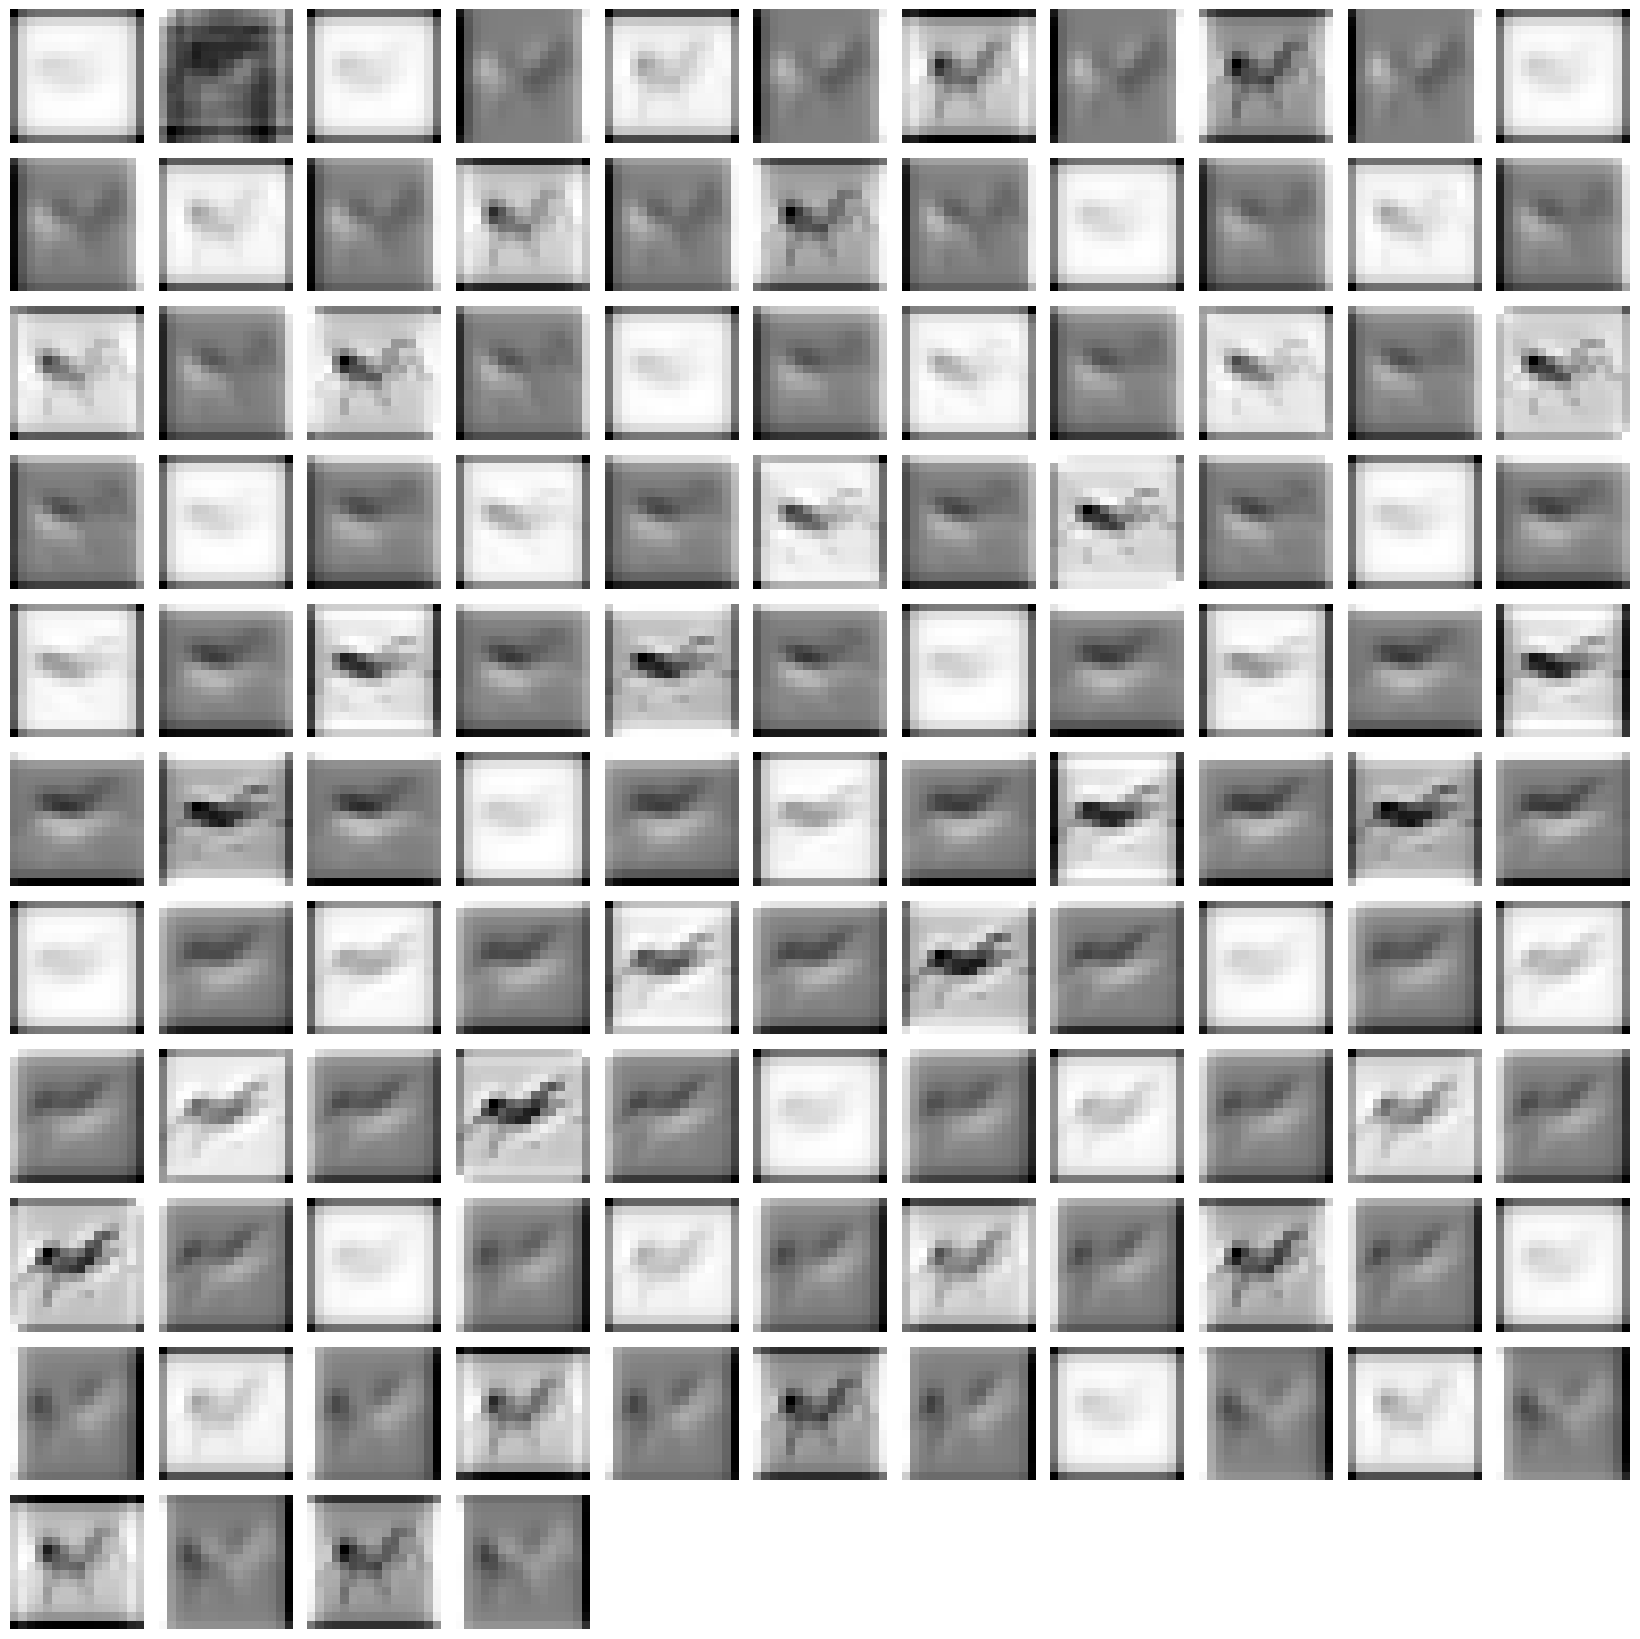

In [5]:
f = features.squeeze(0).cpu()           # shape [N, 1024]
n = f.shape[0]
size = int(math.sqrt(f.shape[1]))
assert size * size == f.shape[1], "expected square (H*W)"

cols = int(math.ceil(math.sqrt(n)))
rows = int(math.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = np.atleast_1d(axes).flatten()

for i in range(rows * cols):
    ax = axes[i]
    if i < n:
        img = f[i].reshape(size, size).numpy()
        ax.imshow(img, cmap="grey")
    ax.axis("off")

plt.tight_layout()
plt.show()